<a href="https://colab.research.google.com/github/KosTeS1/test-external/blob/new-branch/Homework_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Домашнее задание 10**
**Тема 10. Корреляция и корреляционный анализ**

---
# Задание 1
## План решения:


1.   Построим график plt x и y
2.   Расчитаем корреляцию
Корреляция Пирсона: измеряет линейную связь
Корреляция Спирмена: измеряет монотонную связь
3.   Проверим статистическую значимость, где p < 0.05 означает статистическую значимость
4.   Построим линейную регрессию
5.   Расчитаем качество модели, коэффициент детерминации R2
6.   Построим график остатков (разницы между фактическими и предсказанными значениями)

=== Анализ связи между жёсткостью воды и смертностью ===



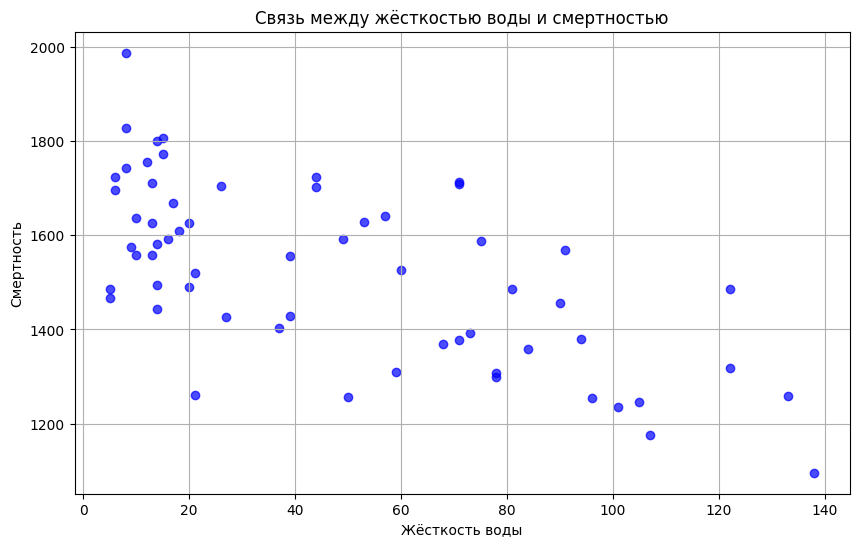

Коэффициент корреляции Пирсона: -0.655
p-значение (Пирсон): 0.0
Коэффициент корреляции Спирмена: -0.632
p-значение (Спирмен): 0.0

Результаты регрессии:
Смертность = 1676.4 + (-3.23) * Жёсткость
p-значение для коэффициента жёсткости: 0.0000

Коэффициент детерминации R²: 0.429


/tmp/ipython-input-93062595.py:38: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Смертность = {model.params[0]:.1f} + ({model.params[1]:.2f}) * Жёсткость")
/tmp/ipython-input-93062595.py:39: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"p-значение для коэффициента жёсткости: {model.pvalues[1]:.4f}")


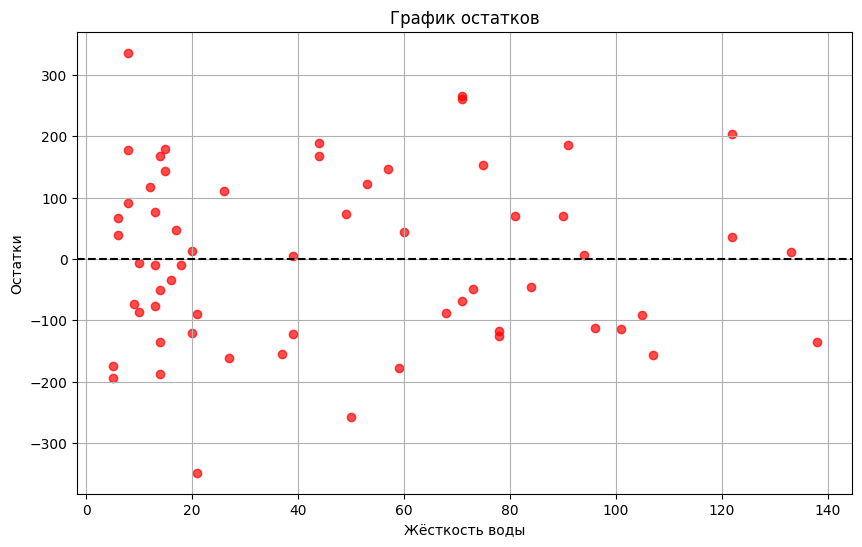


=== ВЫВОД ===
Связь между жёсткостью воды и смертностью существует и статистически значима.
Обнаружена отрицательная связь: чем выше жёсткость воды, тем ниже смертность.
Сила связи: 0.655 (умеренная)
Модель объясняет 42.9% вариации смертности


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

# Загрузка данных
water = pd.read_csv('water.csv')

print("=== Анализ связи между жёсткостью воды и смертностью ===\n")

# Шаг 1: Точечный график
plt.figure(figsize=(10, 6))
plt.scatter(water['hardness'], water['mortality'], alpha=0.7, color='blue')
plt.xlabel('Жёсткость воды')
plt.ylabel('Смертность')
plt.title('Связь между жёсткостью воды и смертностью')
plt.grid(True)
plt.show()

# Шаг 2: Коэффициенты корреляции
pearson_cor, pearson_p = stats.pearsonr(water['hardness'], water['mortality'])
spearman_cor, spearman_p = stats.spearmanr(water['hardness'], water['mortality'])

print("Коэффициент корреляции Пирсона:", round(pearson_cor, 3))
print("p-значение (Пирсон):", round(pearson_p, 4))
print("Коэффициент корреляции Спирмена:", round(spearman_cor, 3))
print("p-значение (Спирмен):", round(spearman_p, 4))

# Шаг 3: Модель линейной регрессии
X = water['hardness']
y = water['mortality']
X_with_const = sm.add_constant(X)  # Добавляем константу

model = sm.OLS(y, X_with_const).fit()

print("\nРезультаты регрессии:")
print(f"Смертность = {model.params[0]:.1f} + ({model.params[1]:.2f}) * Жёсткость")
print(f"p-значение для коэффициента жёсткости: {model.pvalues[1]:.4f}")

# Шаг 4: Коэффициент детерминации
r_squared = model.rsquared
print(f"\nКоэффициент детерминации R²: {r_squared:.3f}")

# Шаг 5: График остатков
plt.figure(figsize=(10, 6))
plt.scatter(water['hardness'], model.resid, alpha=0.7, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel('Жёсткость воды')
plt.ylabel('Остатки')
plt.title('График остатков')
plt.grid(True)
plt.show()

# Вывод со статистической значимостью
print("\n=== ВЫВОД ===")
if pearson_p < 0.05:
    print("Связь между жёсткостью воды и смертностью существует и статистически значима.")
else:
    print("Связь между жёсткостью воды и смертностью не является статистически значимой.")

if pearson_cor < 0:
    print("Обнаружена отрицательная связь: чем выше жёсткость воды, тем ниже смертность.")
else:
    print("Обнаружена положительная связь: чем выше жёсткость воды, тем выше смертность.")

print(f"Сила связи: {abs(pearson_cor):.3f} ({'слабая' if abs(pearson_cor) < 0.3 else 'умеренная' if abs(pearson_cor) < 0.7 else 'сильная'})")
print(f"Модель объясняет {r_squared*100:.1f}% вариации смертности")

# Задание 2
**Анализ для северных и южных городов отдельно**
## План решения:


1.   Разделение данных на группы: северные и южные города
2.   Построили plt жёсткость воды и смертность для северных городов. Посчитали корреляцию и регрессию
3.   Построили plt жёсткость воды и смертность для южных городов. Посчитали корреляцию и регрессию
4.   Сравнили обе группы




Задание 2: Анализ по группам
Северные города: 35
Южные города: 26

--- Северные города ---


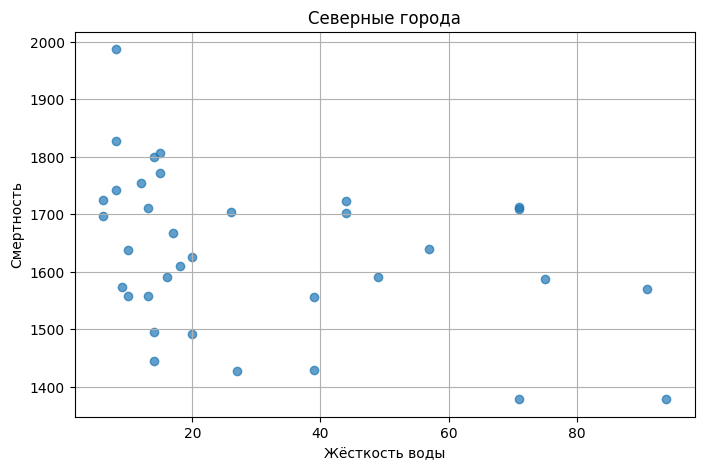

Корреляция Пирсона: -0.369 (p=0.0293)
Корреляция Спирмена: -0.404
Регрессия: Смертность = 1692.3 + (-1.93)*Жёсткость
R²: 0.136


/tmp/ipython-input-834128138.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Регрессия: Смертность = {model.params[0]:.1f} + ({model.params[1]:.2f})*Жёсткость")


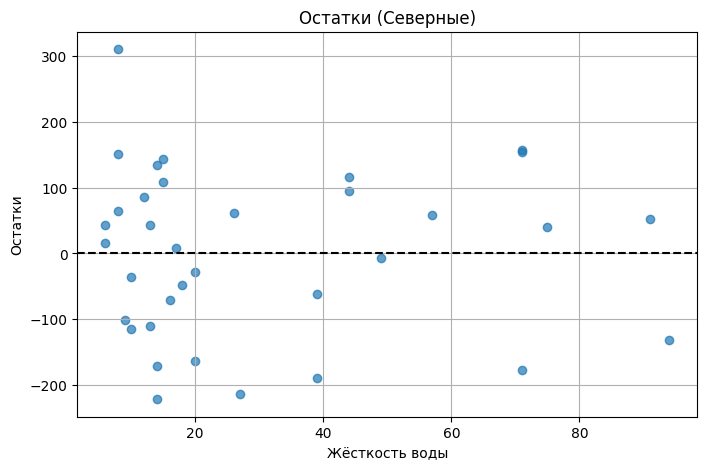


--- Южные города ---


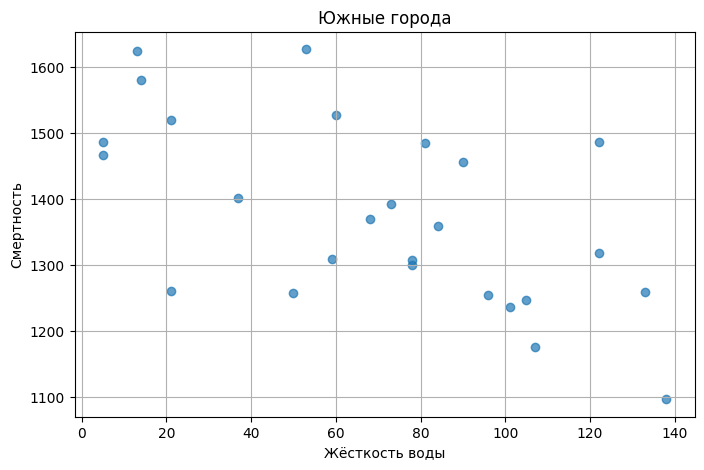

Корреляция Пирсона: -0.602 (p=0.0011)
Корреляция Спирмена: -0.596
Регрессия: Смертность = 1522.8 + (-2.09)*Жёсткость
R²: 0.363


/tmp/ipython-input-834128138.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"Регрессия: Смертность = {model.params[0]:.1f} + ({model.params[1]:.2f})*Жёсткость")


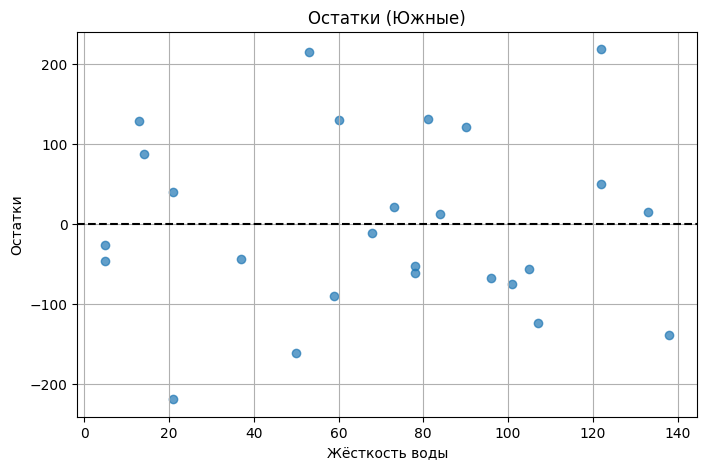


СРАВНЕНИЕ ГРУПП
                Север      Юг        
-----------------------------------
Корреляция      -0.369*         -0.602*        
R²              0.136          0.363         
Значимость      да         да        
* p < 0.05

ВЫВОД:
Зависимость сохраняется в обеих группах - везде есть значимая отрицательная связь


In [11]:
print("\n" + "="*50)
print("Задание 2: Анализ по группам")
print("="*50)

# Разделяем данные
north = water[water['location'] == 'North']
south = water[water['location'] == 'South']

print(f"Северные города: {len(north)}")
print(f"Южные города: {len(south)}")

# Функция для анализа группы
def analyze_group(data, name):
    print(f"\n--- {name} города ---")

    # Точечный график
    plt.figure(figsize=(8, 5))
    plt.scatter(data['hardness'], data['mortality'], alpha=0.7)
    plt.xlabel('Жёсткость воды')
    plt.ylabel('Смертность')
    plt.title(f'{name} города')
    plt.grid(True)
    plt.show()

    # Корреляции
    pearson_cor, pearson_p = stats.pearsonr(data['hardness'], data['mortality'])
    spearman_cor, spearman_p = stats.spearmanr(data['hardness'], data['mortality'])

    print(f"Корреляция Пирсона: {pearson_cor:.3f} (p={pearson_p:.4f})")
    print(f"Корреляция Спирмена: {spearman_cor:.3f}")

    # Регрессия
    X = sm.add_constant(data['hardness'])
    model = sm.OLS(data['mortality'], X).fit()

    print(f"Регрессия: Смертность = {model.params[0]:.1f} + ({model.params[1]:.2f})*Жёсткость")
    print(f"R²: {model.rsquared:.3f}")

    # График остатков
    plt.figure(figsize=(8, 5))
    plt.scatter(data['hardness'], model.resid, alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='--')
    plt.xlabel('Жёсткость воды')
    plt.ylabel('Остатки')
    plt.title(f'Остатки ({name})')
    plt.grid(True)
    plt.show()

    return pearson_cor, pearson_p, model.rsquared

# Анализируем обе группы
north_cor, north_p, north_r2 = analyze_group(north, "Северные")
south_cor, south_p, south_r2 = analyze_group(south, "Южные")

# Сравниваем результаты
print("\n" + "="*50)
print("СРАВНЕНИЕ ГРУПП")
print("="*50)

print(f"{'':<15} {'Север':<10} {'Юг':<10}")
print(f"{'-'*35}")
print(f"{'Корреляция':<15} {north_cor:.3f}{'*' if north_p < 0.05 else '':<9} {south_cor:.3f}{'*' if south_p < 0.05 else '':<9}")
print(f"{'R²':<15} {north_r2:.3f}{'':<9} {south_r2:.3f}{'':<9}")
print(f"{'Значимость':<15} {'да' if north_p < 0.05 else 'нет':<10} {'да' if south_p < 0.05 else 'нет':<10}")
print("* p < 0.05")

print("\nВЫВОД:")
if north_p < 0.05 and south_p < 0.05:
    print("Зависимость сохраняется в обеих группах - везде есть значимая отрицательная связь")
else:
    print("Зависимость не сохраняется одинаково в обеих группах")